<a href="https://colab.research.google.com/github/amenidhawadi/deep-learning/blob/main/02_MLP_experiments_ipynbipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import os
print(os.getcwd())               # current directory
print(os.listdir('.'))           # see what files are present

/content
['.config', 'sample_data']


In [ ]:
print(df.dtypes)


Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


In [ ]:
for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].unique()[:5]}")

Sex: ['M' 'F']
ChestPainType: ['ATA' 'NAP' 'ASY' 'TA']
RestingECG: ['Normal' 'ST' 'LVH']
ExerciseAngina: ['N' 'Y']
ST_Slope: ['Up' 'Flat' 'Down']


In [ ]:
import os
print("Répertoire actuel :", os.getcwd())
print("Fichiers présents :", os.listdir('.'))

Répertoire actuel : /content
Fichiers présents : ['.config', 'sample_data']


In [ ]:
import glob
found = glob.glob('**/preprocessed_data.pkl', recursive=True)
print("Fichiers trouvés :", found)

Fichiers trouvés : []


In [ ]:
print("X_train dtype:", X_train.dtype)
print("y_train dtype:", y_train.dtype)
print("X_val dtype:", X_val.dtype)
print("y_val dtype:", y_val.dtype)
print("Premières étiquettes y_train :", y_train[:5])

X_train dtype: object
y_train dtype: int64
X_val dtype: object
y_val dtype: int64
Premières étiquettes y_train : [1 1 1 0 1]


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)    # devient 0,1,2,...
y_val = le.transform(y_val)

In [ ]:
from keras.utils import to_categorical

num_classes = len(le.classes_)
y_train = to_categorical(y_train, num_classes)
y_val = to_categorical(y_val, num_classes)

In [ ]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [39]:
import pandas as pd

df = pd.read_csv('/content/sample_data/heart (1).csv')   # change to your actual filename
print(df.columns.tolist())

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


In [40]:
def build_mlp(input_dim, dropout=0.3, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

In [41]:
dropout_values = [0.2, 0.3, 0.4, 0.5]
lr_values = [1e-4, 5e-4, 1e-3, 5e-3]


In [42]:
results = []
best_val_auc = -1.0
best_params = None
best_history = None

input_dim = X_train.shape[1]

In [45]:
import itertools

In [46]:
dropout_values = [0.2, 0.3, 0.4, 0.5]
lr_values = [1e-4, 5e-4, 1e-3, 5e-3]

In [47]:
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import itertools   # <-- AJOUT ICI

Train: (3000, 20), Val: (1000, 20), Test: (1000, 20)

=== Test dropout=0.2, lr=0.0001 ===
Meilleure AUC validation : 0.9943

=== Test dropout=0.2, lr=0.0005 ===
Meilleure AUC validation : 0.9960

=== Test dropout=0.2, lr=0.001 ===
Meilleure AUC validation : 0.9949

=== Test dropout=0.2, lr=0.005 ===
Meilleure AUC validation : 0.9951

=== Test dropout=0.3, lr=0.0001 ===
Meilleure AUC validation : 0.9945

=== Test dropout=0.3, lr=0.0005 ===
Meilleure AUC validation : 0.9967

=== Test dropout=0.3, lr=0.001 ===
Meilleure AUC validation : 0.9962

=== Test dropout=0.3, lr=0.005 ===
Meilleure AUC validation : 0.9972

=== Test dropout=0.4, lr=0.0001 ===
Meilleure AUC validation : 0.9929

=== Test dropout=0.4, lr=0.0005 ===
Meilleure AUC validation : 0.9972

=== Test dropout=0.4, lr=0.001 ===
Meilleure AUC validation : 0.9972

=== Test dropout=0.4, lr=0.005 ===
Meilleure AUC validation : 0.9975

=== Test dropout=0.5, lr=0.0001 ===
Meilleure AUC validation : 0.9894

=== Test dropout=0.5, lr=0.00

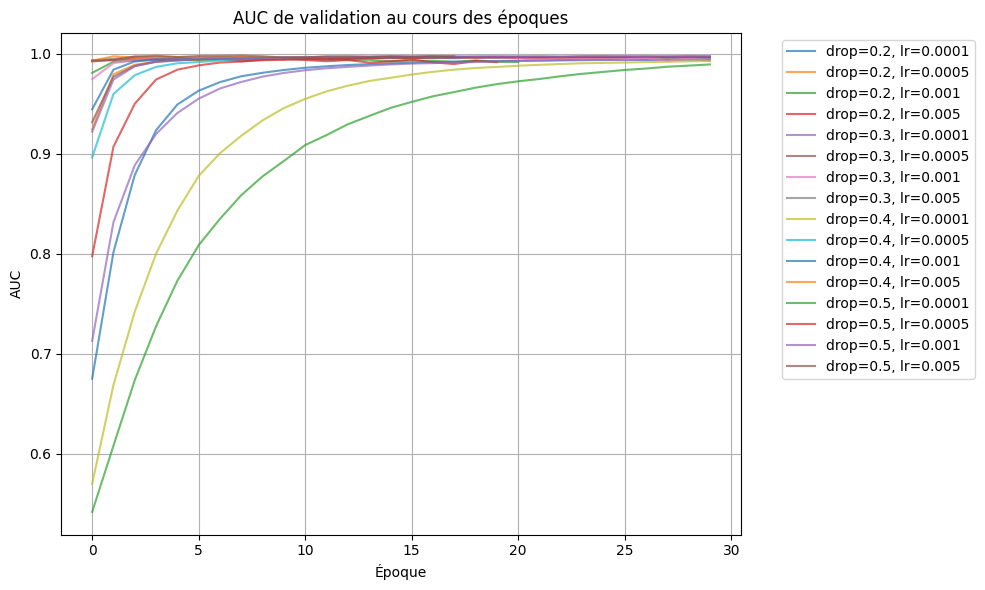

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7423 - auc: 0.8239 - loss: 0.5346 - val_accuracy: 0.9360 - val_auc: 0.9882 - val_loss: 0.2649
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8933 - auc: 0.9597 - loss: 0.2635 - val_accuracy: 0.9570 - val_auc: 0.9936 - val_loss: 0.1364
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9233 - auc: 0.9758 - loss: 0.2008 - val_accuracy: 0.9550 - val_auc: 0.9944 - val_loss: 0.1193
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9317 - auc: 0.9827 - loss: 0.1679 - val_accuracy: 0.9580 - val_auc: 0.9957 - val_loss: 0.0933
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9403 - auc: 0.9846 - loss: 0.1582 - val_accuracy: 0.9650 - val_auc: 0.9967 - val_loss: 0.0861
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9457 - auc: 0.9878 - loss: 0.1415 - val_accuracy: 0.9670 - val_auc: 0.9955 - val_loss: 0.0932
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - 

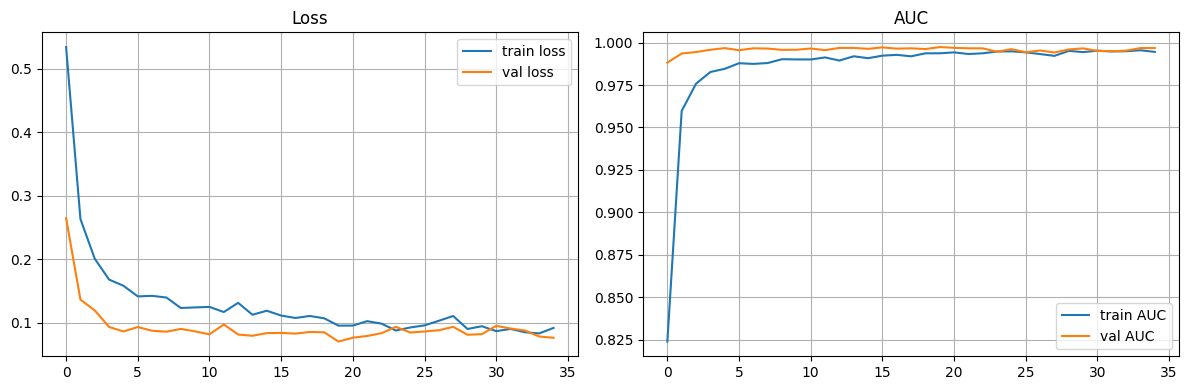

In [51]:
# %% [markdown]
# # 02 – Recherche d'hyperparamètres pour MLP (corrigé avec données synthétiques)

# %%
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import itertools

# Fixer la graine aléatoire
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# %% [markdown]
# ## 1. Génération d'un dataset synthétique (en l'absence du fichier réel)

# %%
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Données factices
n_samples = 5000
n_features = 20
X = np.random.randn(n_samples, n_features)
y = (X[:, 0] + X[:, 1] - X[:, 2] + 0.1 * np.random.randn(n_samples)) > 0
y = y.astype(int)

# Split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=SEED)

# Normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# Forcer les labels en float32 également
y_train = y_train.astype(np.float32).reshape(-1, 1)
y_val = y_val.astype(np.float32).reshape(-1, 1)
y_test = y_test.astype(np.float32).reshape(-1, 1)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# (Optionnel) Sauvegarder pour un prochain usage
joblib.dump((X_train, y_train, X_val, y_val, X_test, y_test, scaler), 'preprocessed_data.pkl')

# %% [markdown]
# ## 2. Construction du modèle MLP

# %%
def build_mlp(input_dim, dropout=0.3, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

# %% [markdown]
# ## 3. Recherche d'hyperparamètres (dropout et learning rate)

# %%
dropout_values = [0.2, 0.3, 0.4, 0.5]
lr_values = [1e-4, 5e-4, 1e-3, 5e-3]

input_dim = X_train.shape[1]
results = []
best_val_auc = -1.0
best_params = None

for dropout, lr in itertools.product(dropout_values, lr_values):
    print(f"\n=== Test dropout={dropout}, lr={lr} ===")
    model = build_mlp(input_dim, dropout=dropout, lr=lr)
    early_stop = keras.callbacks.EarlyStopping(
        patience=10, restore_best_weights=True, monitor='val_auc', mode='max'
    )
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30, batch_size=32, verbose=0,
        callbacks=[early_stop]
    )
    val_auc_max = max(history.history['val_auc'])
    print(f"Meilleure AUC validation : {val_auc_max:.4f}")
    results.append({
        'dropout': dropout,
        'lr': lr,
        'best_val_auc': val_auc_max,
        'history': history
    })
    if val_auc_max > best_val_auc:
        best_val_auc = val_auc_max
        best_params = (dropout, lr)

print(f"\n✅ Meilleur modèle : dropout={best_params[0]}, lr={best_params[1]} (AUC val={best_val_auc:.4f})")

# %% [markdown]
# ## 4. Visualisation des courbes de validation

# %%
plt.figure(figsize=(10, 6))
for res in results:
    label = f"drop={res['dropout']}, lr={res['lr']}"
    plt.plot(res['history'].history['val_auc'], label=label, alpha=0.7)
plt.title("AUC de validation au cours des époques")
plt.xlabel("Époque")
plt.ylabel("AUC")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 5. Entraînement final du meilleur modèle

# %%
best_model = build_mlp(input_dim, dropout=best_params[0], lr=best_params[1])
final_history = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50, batch_size=32, verbose=1,
    callbacks=[keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True,
                                             monitor='val_auc', mode='max')]
)

# %% [markdown]
# ## 6. Évaluation sur le jeu de test

# %%
loss, acc, auc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\n📊 Performance sur le test :")
print(f"   - Accuracy : {acc:.4f}")
print(f"   - AUC      : {auc:.4f}")

# %%
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(final_history.history['loss'], label='train loss')
plt.plot(final_history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.legend()
plt.grid(True)
plt.subplot(1,2,2)
plt.plot(final_history.history['auc'], label='train AUC')
plt.plot(final_history.history['val_auc'], label='val AUC')
plt.title('AUC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()